<a href="https://colab.research.google.com/github/aliakseizvertouski/olist/blob/main/olist_geo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ активности клиентов по geo

In [61]:
!git clone https://github.com/aliakseizvertouski/olist.git

fatal: destination path 'olist' already exists and is not an empty directory.


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [63]:
customers = pd.read_csv('/content/olist/olist_customers_dataset.csv')
geo = pd.read_csv('/content/olist/olist_geolocation_dataset.csv')
order_items = pd.read_csv('/content/olist/olist_order_items_dataset.csv')
order_payments = pd.read_csv('/content/olist/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('/content/olist/olist_order_reviews_dataset.csv')
orders = pd.read_csv('/content/olist/olist_orders_dataset.csv')
products = pd.read_csv('/content/olist/olist_products_dataset.csv')
sellers = pd.read_csv('/content/olist/olist_sellers_dataset.csv')
product_category_name_translation = pd.read_csv('/content/olist/product_category_name_translation.csv')

In [64]:
print (f'customers.columns: {customers.columns} \n')
print (f'geo.columns: {geo.columns} \n')
print (f'order_items.columns: {order_items.columns} \n')
print (f'order_payments.columns: {order_payments.columns} \n')
print (f'order_reviews.columns: {order_reviews.columns} \n')
print (f'orders.columns: {products.columns} \n')
print (f'products.columns: {products.columns} \n')
print (f'sellers.columns: {sellers.columns} \n')
print (f'product_category_name_translation.columns: {product_category_name_translation.columns}')

customers.columns: Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object') 

geo.columns: Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object') 

order_items.columns: Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object') 

order_payments.columns: Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object') 

order_reviews.columns: Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object') 

orders.columns: Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'produ

## Количество заказов и оборот по GEO

In [65]:
df_geo = customers.merge(orders, on='customer_id').merge(order_items, on='order_id')

sales_stats = df_geo.groupby('customer_state').agg(
    sum_sales=('order_id', 'count'),
    total_revenue=('price', 'sum')
).reset_index()

sales_stats = sales_stats.sort_values(by='total_revenue', ascending=False)

sales_stats

,customer_state,sum_sales,total_revenue
25,SP,47449,5202955.05
18,RJ,14579,1824092.67
10,MG,13129,1585308.03
22,RS,6235,750304.02
17,PR,5740,683083.76
23,SC,4176,520553.34
4,BA,3799,511349.99
6,DF,2406,302603.94
8,GO,2333,294591.95
7,ES,2256,275037.31


In [66]:
sales_stats.to_csv('geo_sales_stats.csv', index=False, sep=';')

## Топ категорий по GEO по каличеству заказов

### Исходные данные

In [67]:
df_geo_cat = order_items[['order_id', 'product_id', 'price']].merge(
    orders[['order_id', 'customer_id']], on='order_id'
).merge(
    customers[['customer_id', 'customer_state']], on='customer_id'
).merge(
    products[['product_id', 'product_category_name']], on='product_id'
).merge(
    product_category_name_translation, on='product_category_name', how='left'
)

df_geo_cat = df_geo_cat.rename(columns={'product_category_name_english': 'category'})
df_geo_cat = df_geo_cat[['customer_state', 'category', 'product_id', 'price']]

df_geo_cat.head()

,customer_state,category,product_id,price
0,RJ,cool_stuff,4244733e06e7ecb4970a6e2683c13e61,58.90
1,SP,pet_shop,e5f2d52b802189ee658865ca93d83a8f,239.90
2,MG,furniture_decor,c777355d18b72b67abbeef9df44fd0fd,199.00
3,SP,perfumery,7634da152a4610f1595efa32f14722fc,12.99
4,SP,garden_tools,ac6c3623068f30de03045865e4e10089,199.90


### Самые популярные категории для каждого региона

In [68]:
cat_geo_stats = df_geo_cat.groupby(['customer_state', 'category'])['product_id'].count().reset_index()
cat_geo_stats = cat_geo_stats.rename(columns={'product_id': 'sales'})

cat_geo_stats = cat_geo_stats.sort_values(by=['customer_state', 'sales'], ascending=[True, False])

cat_geo_stats['rank'] = cat_geo_stats.groupby('customer_state').cumcount() + 1

top_3_per_state = cat_geo_stats[cat_geo_stats['rank'] <= 3]

top_3_per_state

,customer_state,category,sales,rank
12,AC,furniture_decor,12,1
6,AC,computers_accessories,9,2
22,AC,sports_leisure,9,3
50,AL,health_beauty,63,1
35,AL,computers_accessories,41,2
...,...,...,...,...
1291,SP,health_beauty,4204,2
1312,SP,sports_leisure,3667,3
1336,TO,health_beauty,36,1
1355,TO,watches_gifts,30,2


### Самые популярные категории для каждого региона (2)

In [69]:
geo_cat_stats = df_geo_cat.groupby(['customer_state', 'category'])['product_id'].count().reset_index()
geo_cat_stats = geo_cat_stats.rename(columns={'product_id': 'sales_count'})

top_geo_cat = geo_cat_stats.sort_values(['customer_state', 'sales_count'], ascending=[True, False])
top_geo_cat = top_geo_cat.groupby('customer_state').head(3)                                                   # черт возьми как же это изящно

top_geo_cat

,customer_state,category,sales_count
12,AC,furniture_decor,12
6,AC,computers_accessories,9
22,AC,sports_leisure,9
50,AL,health_beauty,63
35,AL,computers_accessories,41
...,...,...,...
1291,SP,health_beauty,4204
1312,SP,sports_leisure,3667
1336,TO,health_beauty,36
1355,TO,watches_gifts,30


In [70]:
top_geo_cat.to_csv('top_geo_cat_sales.csv', index=False, sep=';')

### Топ категорий по выручеке для кадждого региона



In [71]:
revenue_stats = df_geo_cat.groupby(['customer_state', 'category'])['price'].sum().reset_index()
revenue_stats = revenue_stats.rename(columns={'price': 'revenue'})

revenue_stats = revenue_stats.sort_values(by=['customer_state', 'revenue'], ascending=[True, False])

revenue_stats['rank'] = revenue_stats.groupby('customer_state').cumcount() + 1

top_3_revenue = revenue_stats[revenue_stats['rank'] <= 3]

top_3_revenue

,customer_state,category,revenue,rank
22,AC,sports_leisure,1677.46,1
26,AC,watches_gifts,1389.60,2
15,AC,health_beauty,1386.58,3
50,AL,health_beauty,12780.26,1
68,AL,watches_gifts,11683.27,2
...,...,...,...,...
1291,SP,health_beauty,462305.22,2
1317,SP,watches_gifts,435009.92,3
1355,TO,watches_gifts,5446.89,1
1351,TO,sports_leisure,5144.32,2


In [72]:
top_3_revenue.to_csv('top_geo_cat_revenue.csv', index=False, sep=';')

### Анализ влияния стоимости доставки на спрос

In [73]:

df_delivery = customers[['customer_id', 'customer_state']].merge(
    orders[['order_id', 'customer_id']], on='customer_id'
).merge(
    order_items[['order_id', 'freight_value', 'price']], on='order_id'
)

delivery_stats = df_delivery.groupby('customer_state').agg(
    total_sales=('order_id', 'count'),     # Спрос: количество проданных товаров
    avg_price=('price', 'mean'),           # Средняя цена товара в штате
    avg_freight=('freight_value', 'mean')  # Средняя стоимость доставки
).reset_index()


delivery_stats['freight_to_price_percent'] = (delivery_stats['avg_freight'] / delivery_stats['avg_price']) * 100

delivery_stats['avg_price'] = delivery_stats['avg_price'].round(2)
delivery_stats['avg_freight'] = delivery_stats['avg_freight'].round(2)
delivery_stats['freight_to_price_percent'] = delivery_stats['freight_to_price_percent'].round(2)

delivery_stats = delivery_stats.sort_values(by='avg_freight', ascending=False)

delivery_stats = delivery_stats.sort_values(by='total_sales', ascending=False)
delivery_stats.head(10)


,customer_state,total_sales,avg_price,avg_freight,freight_to_price_percent
25,SP,47449,109.65,15.15,13.81
18,RJ,14579,125.12,20.96,16.75
10,MG,13129,120.75,20.63,17.09
22,RS,6235,120.34,21.74,18.06
17,PR,5740,119.00,20.53,17.25
23,SC,4176,124.65,21.47,17.22
4,BA,3799,134.60,26.36,19.59
6,DF,2406,125.77,21.04,16.73
8,GO,2333,126.27,22.77,18.03
7,ES,2256,121.91,22.06,18.09


In [74]:
delivery_stats.to_csv('delivery_impact.csv', index=False, sep=';')

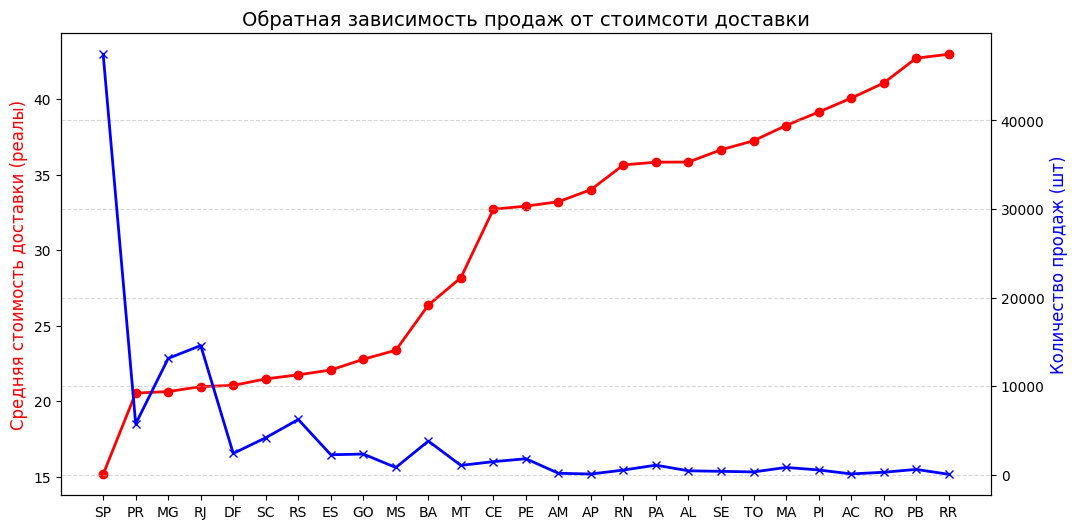

In [77]:
plot_data = delivery_stats.sort_values(by='avg_freight', ascending=True)

plt.figure(figsize=(12, 6))

plt.plot(plot_data['customer_state'], plot_data['avg_freight'], color='red', marker='o', linewidth=2)
plt.ylabel('Средняя стоимость доставки (реалы)', color='red', fontsize=12)

ax2 = plt.twinx()

ax2.plot(plot_data['customer_state'], plot_data['total_sales'], color='blue', marker='x', linewidth=2)
ax2.set_ylabel('Количество продаж (шт)', color='blue', fontsize=12)

plt.title('Обратная зависимость продаж от стоимсоти доставки', fontsize=14)
plt.xlabel('Штаты (отсортированы по росту стоимости доставки)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()